# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from myutil import evaluate_skewness

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [2]:
# Load and view a smaple of the data
survey = pd.read_csv('data.csv')
survey.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,testelapse,country,fromgoogle,engnat,age,education,gender,race,religion,hand
0,4,1,5,1,5,1,5,1,4,1,...,232,US,2,1,22,3,1,3,2,3
1,1,5,1,4,2,5,5,4,1,5,...,247,CA,2,1,14,1,2,6,1,1
2,1,2,1,1,5,4,3,2,1,4,...,6774,NL,2,2,30,4,1,1,1,2
3,1,4,1,5,1,4,5,4,3,5,...,1072,US,2,1,18,2,2,3,2,2
4,5,1,5,1,5,1,5,1,3,1,...,226,US,2,1,22,3,1,3,2,3


---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

In [3]:
# Filter your data to include Q1 to Q44 and hand
q_cols = [f'Q{i}' for i in range(1, 45)]
survey = survey[q_cols + ['hand']]
survey.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
0,4,1,5,1,5,1,5,1,4,1,...,1,1,1,5,5,5,1,5,1,3
1,1,5,1,4,2,5,5,4,1,5,...,4,4,4,1,3,1,4,4,5,1
2,1,2,1,1,5,4,3,2,1,4,...,2,4,2,1,4,2,2,2,2,2
3,1,4,1,5,1,4,5,4,3,5,...,1,3,4,1,2,1,1,1,3,2
4,5,1,5,1,5,1,5,1,3,1,...,1,1,1,5,5,5,1,5,1,3


### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [4]:
# Check Data Information
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q1      4184 non-null   int64
 1   Q2      4184 non-null   int64
 2   Q3      4184 non-null   int64
 3   Q4      4184 non-null   int64
 4   Q5      4184 non-null   int64
 5   Q6      4184 non-null   int64
 6   Q7      4184 non-null   int64
 7   Q8      4184 non-null   int64
 8   Q9      4184 non-null   int64
 9   Q10     4184 non-null   int64
 10  Q11     4184 non-null   int64
 11  Q12     4184 non-null   int64
 12  Q13     4184 non-null   int64
 13  Q14     4184 non-null   int64
 14  Q15     4184 non-null   int64
 15  Q16     4184 non-null   int64
 16  Q17     4184 non-null   int64
 17  Q18     4184 non-null   int64
 18  Q19     4184 non-null   int64
 19  Q20     4184 non-null   int64
 20  Q21     4184 non-null   int64
 21  Q22     4184 non-null   int64
 22  Q23     4184 non-null   int64
 23  Q24     4184 non-null   

In [5]:
# Summary Stat.
survey.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
count,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,...,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000
mean,1.962715,3.829589,2.846558,3.186902,2.865440,3.672084,3.216539,3.184512,2.761233,3.522945,...,2.610660,3.465344,2.798757,2.569312,2.984226,3.385277,2.704828,2.676386,2.736616,1.190966
std,1.360291,1.551683,1.664804,1.476879,1.545798,1.342238,1.490733,1.387382,1.511805,1.242890,...,1.409707,1.521460,1.413584,1.621772,1.483752,1.423055,1.544345,1.523097,1.471845,0.495357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,3.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,...,2.000000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,1.000000
75%,3.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,5.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000


In [6]:
# Check for nulls
survey.isnull().sum()

Q1      0
Q2      0
Q3      0
Q4      0
Q5      0
Q6      0
Q7      0
Q8      0
Q9      0
Q10     0
Q11     0
Q12     0
Q13     0
Q14     0
Q15     0
Q16     0
Q17     0
Q18     0
Q19     0
Q20     0
Q21     0
Q22     0
Q23     0
Q24     0
Q25     0
Q26     0
Q27     0
Q28     0
Q29     0
Q30     0
Q31     0
Q32     0
Q33     0
Q34     0
Q35     0
Q36     0
Q37     0
Q38     0
Q39     0
Q40     0
Q41     0
Q42     0
Q43     0
Q44     0
hand    0
dtype: int64

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> Q1–Q44 contain **ordinal** values: answers on a 5-point Likert scale (1=Disagree, 3=Neutral, 5=Agree). They are ordered categorical ratings, not continuous measurements.

__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

In [7]:
# Check correlation using 'spearman'
corr_matrix = survey.corr(method='spearman')
corr_matrix['hand'].drop('hand').sort_values(ascending=False)

Q35    0.072926
Q3     0.040980
Q17    0.040889
Q25    0.040065
Q1     0.038819
Q5     0.034693
Q29    0.031818
Q7     0.030956
Q26    0.027231
Q27    0.025522
Q33    0.022395
Q38    0.019970
Q31    0.018701
Q37    0.017141
Q13    0.013306
Q43    0.012685
Q11    0.012487
Q4     0.011445
Q9     0.011307
Q44    0.010204
Q39    0.006149
Q19    0.004445
Q28    0.003000
Q21    0.002729
Q15    0.002207
Q34    0.001762
Q16   -0.001207
Q42   -0.005810
Q41   -0.007129
Q36   -0.008183
Q12   -0.008557
Q32   -0.013092
Q6    -0.014195
Q30   -0.016582
Q10   -0.018156
Q2    -0.019378
Q40   -0.020316
Q24   -0.022088
Q18   -0.022297
Q14   -0.023100
Q20   -0.024022
Q22   -0.028688
Q8    -0.030309
Q23   -0.032213
Name: hand, dtype: float64

__Inspect the Target__

**Quick Question:** What does each number in the target column represent?

> Per the codebook: **1 = Right-handed, 2 = Left-handed, 3 = Both-handed**. The distribution also contains a **0**, which is NOT documented in the codebook — that's what's off.

In [8]:
# Target Distribution, What do the numbers represents? hmmm...something is off. What do you notice?
survey['hand'].value_counts()

hand
1    3542
2     452
3     179
0      11
Name: count, dtype: int64

In [9]:
# What needs to be removed from the Target?
# The undocumented 0 values (not in the codebook) need to be removed
survey = survey[survey['hand'] != 0]
survey['hand'].value_counts()

hand
1    3542
2     452
3     179
Name: count, dtype: int64

In [10]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?

# I choose option 1: strictly focus on Left-handed only.
# 1=Right -> 0, 2=Left -> 1, 3=Both -> 0
survey['hand'] = survey['hand'].map({1: 0, 2: 1, 3: 0})
survey['hand'].value_counts()

hand
0    3721
1     452
Name: count, dtype: int64

## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [11]:
# Identify your X and y
X = survey.drop(columns='hand')
y = survey['hand']

In [12]:
# Split the data to train and test for each X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [13]:
# SVM Base Model
svm_base = Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))])
svm_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
# Random Forest Base Model
rf_base = Pipeline([('rf', RandomForestClassifier(random_state=42))])
rf_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [15]:
# XGBoost Base Model
xgboost_base = Pipeline([('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))])
xgboost_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[<U3](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


__Checking the Base Models performance__

In [16]:
# SVM Base Model Result
print("SVM Train Accuracy:", round(svm_base.score(X_train, y_train), 4))
print("SVM Test Accuracy:", round(svm_base.score(X_test, y_test), 4))

SVM Train Accuracy: 0.8922
SVM Test Accuracy: 0.8922


In [17]:
# Random Forest Base Model Result
print("RF Train Accuracy:", round(rf_base.score(X_train, y_train), 4))
print("RF Test Accuracy:", round(rf_base.score(X_test, y_test), 4))

RF Train Accuracy: 1.0
RF Test Accuracy: 0.891


In [18]:
# XGBoost Model Result
print("XGBoost Train Accuracy:", round(xgboost_base.score(X_train, y_train), 4))
print("XGBoost Test Accuracy:", round(xgboost_base.score(X_test, y_test), 4))

XGBoost Train Accuracy: 1.0
XGBoost Test Accuracy: 0.8898


__Comparing the base model performance__

In [19]:
# This is one good function to add to you collection
def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """
    
    # Generate predictions
    y_pred = model.predict(X_test)
    
    # Display the Classification Report
    print("======================================================")
    print("                CLASSIFICATION REPORT                 ")
    print("======================================================")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0.0))
    
    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

__1. SVM Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       835
      macro avg       0.45      0.50      0.47       835
   weighted avg       0.80      0.89      0.84       835



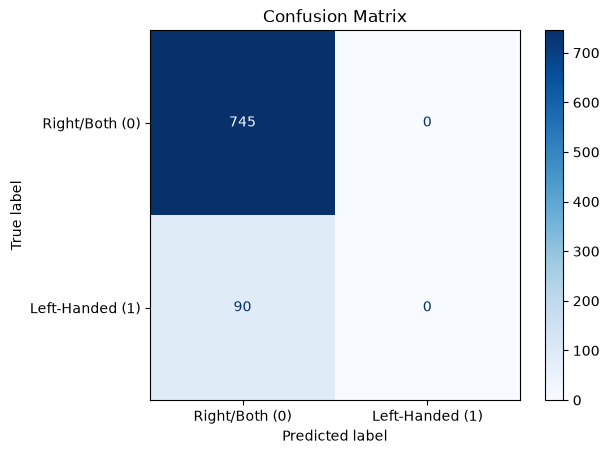

In [20]:
# SVM Base Model Performance
target_classes = ['Right/Both (0)', 'Left-Handed (1)']
evaluate_model_performance(svm_base, X_test, y_test, target_classes)

__2. Random Forest Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       835
      macro avg       0.45      0.50      0.47       835
   weighted avg       0.80      0.89      0.84       835



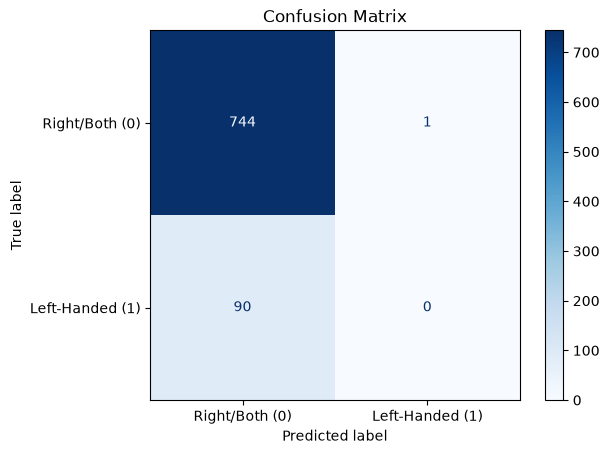

In [21]:
# Random Forest Base Model Performance
evaluate_model_performance(rf_base, X_test, y_test, target_classes)

__3. XGBoost Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.25      0.01      0.02        90

       accuracy                           0.89       835
      macro avg       0.57      0.50      0.48       835
   weighted avg       0.82      0.89      0.84       835



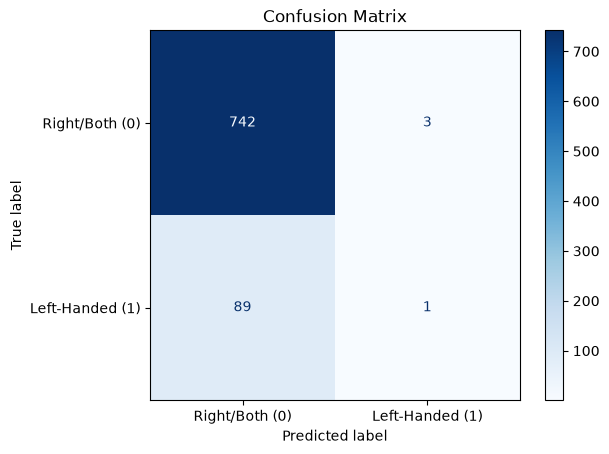

In [22]:
# XGBoost Base Model Performance
evaluate_model_performance(xgboost_base, X_test, y_test, target_classes)

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [23]:
# SVM Grid Search Parameters
svm_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01]
}

In [24]:
# Random Forest Grid Search Parameters
rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10]
}

In [25]:
# XXGBoost Grid Search Parameters
xgboost_param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 6],
    'xgb__learning_rate': [0.05, 0.1]
}

__Setting up and fitting GridSearch__

Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale'}
Best CV F1-Score: 0.08075089440224181
                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      0.97      0.93       745
Left-Handed (1)       0.11      0.03      0.05        90

       accuracy                           0.87       835
      macro avg       0.50      0.50      0.49       835
   weighted avg       0.81      0.87      0.83       835



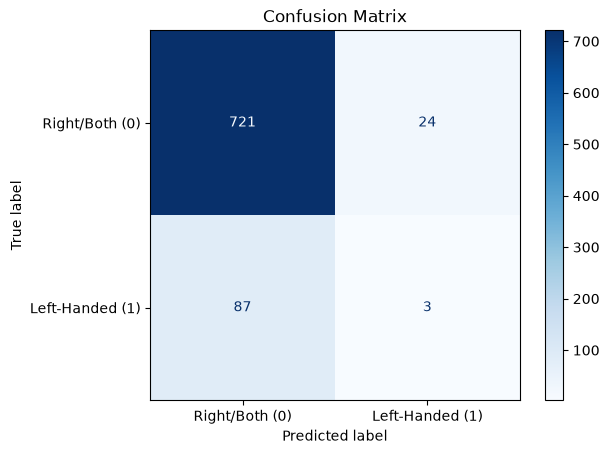

In [26]:
# Setting up and fitting GridSearch for SVM
grid_svm = GridSearchCV(svm_base, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_svm.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_svm.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'rf__max_depth': None, 'rf__n_estimators': 100}
Best CV F1-Score: 0.0
                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       835
      macro avg       0.45      0.50      0.47       835
   weighted avg       0.80      0.89      0.84       835



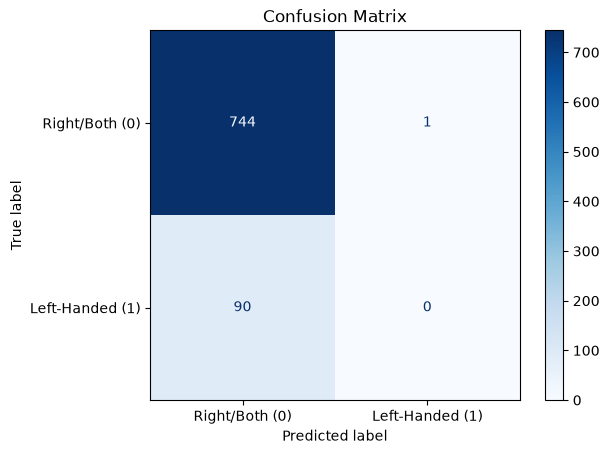

In [27]:
# Setting up and fitting GridSearch for Random Forest
grid_rf = GridSearchCV(rf_base, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_rf.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}
Best CV F1-Score: 0.020986101617680566
                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       835
      macro avg       0.45      0.50      0.47       835
   weighted avg       0.80      0.89      0.84       835



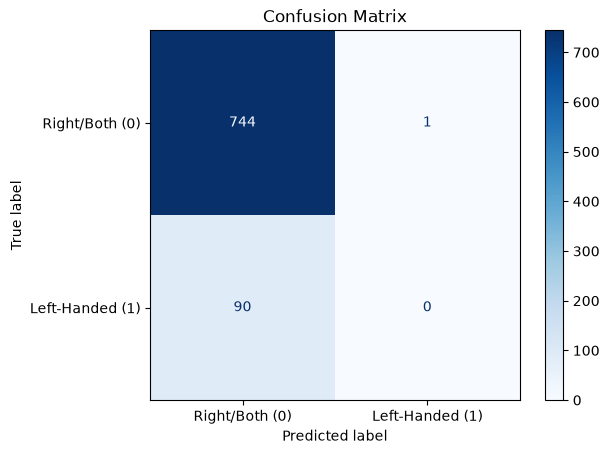

In [28]:
# Setting up and fitting GridSearch for XGBoost
xgboost_svm = GridSearchCV(xgboost_base, xgboost_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
xgboost_svm.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", xgboost_svm.best_params_)
print("Best CV F1-Score:", xgboost_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(xgboost_svm.best_estimator_, X_test, y_test, target_classes)

## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here

> __Final Model Selection: Tuned SVM__

> __*Justification:*__
> I selected the Tuned SVM (C=10, gamma='scale') because it was the only model that produced any meaningful predictions for the minority Left-Handed class. Looking at accuracy alone is very misleading here: the base models all scored ~89% accuracy, yet their F1-Score for Left-Handed was 0.00 — they "cheated" by predicting everyone as Right/Both and never catching a single left-handed person. That's why I relied on F1-Score/Recall for the minority class rather than accuracy: with only 452 left-handed individuals out of 4,173 (~11%), an accuracy metric is dominated by the majority class.
>
> After tuning, SVM reached a Left-Handed F1 of ~0.05 (recall 0.03) — modest, but real. Random Forest and XGBoost were rejected because even after Grid Search they scored F1 = 0.00 for the Left-Handed class; both overfit the training data (100% train accuracy) and simply collapsed into the majority class on test data. XGBoost's CV F1 was near zero (0.02), confirming no reliable signal.
>
> In the context of the behavioral study, the honest finding is that the 44 psychological questions carry almost no signal for handedness — the strongest Spearman correlations with hand were under 0.08. The SVM's interpretability limitations are a secondary concern; the primary takeaway for the psychology professor is that these questionnaire items are not good predictors of left-handedness and the study needs different or better measures. (If we had found a strong signal, SVM's RBF kernel "black box" would have been a reason to prefer a feature-based model instead.)

### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

In [29]:
# Enter you process....
# Reload the full data to bring the demographic columns back
demog = pd.read_csv('data.csv')
demog_cols = ['age', 'gender', 'education', 'race', 'religion', 'engnat']
demog[demog_cols + ['hand']].info()
demog[demog_cols].describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4184 non-null   int64
 1   gender     4184 non-null   int64
 2   education  4184 non-null   int64
 3   race       4184 non-null   int64
 4   religion   4184 non-null   int64
 5   engnat     4184 non-null   int64
 6   hand       4184 non-null   int64
dtypes: int64(7)
memory usage: 228.9 KB


,age,gender,education,race,religion,engnat
count,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000
mean,30.370698,1.654398,2.317878,5.013623,2.394359,1.239962
std,367.201726,0.640915,0.874264,1.970996,2.184164,0.440882
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,1.000000,2.000000,5.000000,1.000000,1.000000
50%,21.000000,2.000000,2.000000,6.000000,2.000000,1.000000
75%,27.000000,2.000000,3.000000,6.000000,2.000000,1.000000
max,23763.000000,3.000000,4.000000,7.000000,7.000000,2.000000


__Preprocessing__

In [30]:
# Enter you process....
# Clean: drop invalid hand (0), unrealistic ages and undocumented gender (0)
demog = demog[demog['hand'] != 0]
demog = demog[(demog['age'] >= 13) & (demog['age'] <= 100)]
demog = demog[demog['gender'] != 0]

# Same target mapping as the main analysis: 1=Right -> 0, 2=Left -> 1, 3=Both -> 0
demog['hand'] = demog['hand'].map({1: 0, 2: 1, 3: 0})

# Behavioral features (Q1-Q44) + one-hot encoded demographics, on the same rows
q_cols = [f'Q{i}' for i in range(1, 45)]
X_behavioral = demog[q_cols]
X_demog = pd.get_dummies(demog[['gender', 'education', 'race', 'religion']], drop_first=True)
X_combined = pd.concat([X_behavioral, X_demog], axis=1)
y_demog = demog['hand']
print("Shape (behavioral + demographics):", X_combined.shape)

Shape (behavioral + demographics): (4092, 48)


__Modeling__

In [ ]:
# Enter you process....
# Reuse the best tuned model from the main analysis (Random Forest with best params)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_combined, y_demog, test_size=0.2, random_state=42, stratify=y_demog)

# Strip the 'rf__' pipeline prefix from the best params
best_rf_params = {k.split('__')[-1]: v for k, v in grid_rf.best_params_.items()}
demog_model = Pipeline([('rf', RandomForestClassifier(**best_rf_params, random_state=42))])
demog_model.fit(X_train_d, y_train_d)
print("Demographic model test accuracy:", round(demog_model.score(X_test_d, y_test_d), 4))

__Evaluating the Model__

In [ ]:
# Enter you process....
evaluate_model_performance(demog_model, X_test_d, y_test_d, target_classes)

#### What was the difference in performance?  

> Adding demographics (age, gender, education, race, religion, engnat, one-hot encoded) barely changed anything: the tuned Random Forest's Left-Handed F1 went from 0.00 (behavioral questions only) to 0.02 (behavioral + demographics), and test accuracy went from 89.1% to 89.4% on the cleaned 4,092-row set. That tiny gain is essentially noise.
>
> Conclusion: demographic information does **not** significantly improve prediction of left-handedness. Neither behavioral questions nor demographics carry meaningful signal in this survey — the models still cannot separate the ~11% left-handed minority from the majority, and both feature sets perform at the same near-majority-only level. For the study, this suggests handedness is not well predicted by the collected variables at all, rather than that one feature type is better than the other.